# CAMS AOD 550nm — Open-Meteo Air Quality API

**Nguồn:** Open-Meteo Air Quality API (dữ liệu từ CAMS Global Reanalysis)  
**Variable:** `aerosol_optical_depth` — AOD tại 550nm  
**Credentials:** Không cần — miễn phí, không đăng ký  

**Output:** `data/processed/cams_aod_daily.csv` → merge vào `daily_merged.csv`

## Cell 1 — Cài đặt

In [4]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openmeteo-requests", "requests-cache", "retry-requests"])
print("Ready.")

Ready.


## Cell 2 — Cấu hình

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import requests, time

ROOT     = Path("D:/Bussiness_plan/Multimodal_PM25")
PROC_DIR = ROOT / "data/processed"; PROC_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR  = ROOT / "data/raw/cams";  RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV  = PROC_DIR / "cams_aod_daily.csv"
MERGED   = PROC_DIR / "daily_merged.csv"

STATIONS = {
    2161292: (21.0152, 105.7999),
    2161306: (21.0500, 105.7400),
    4946811: (21.0491, 105.8831),
    4946812: (21.0031, 105.7947),
    4946813: (21.0052, 105.8418),
    6123215: (20.9933, 105.9441),
}

DATE_START = "2024-01-01"
DATE_END   = "2026-05-15"

# Open-Meteo gioi han ~1 nam/request -> chia thanh cac chunk
DATE_CHUNKS = [
    ("2024-01-01", "2024-12-31"),
    ("2025-01-01", "2025-12-31"),
    ("2026-01-01", "2026-05-15"),
]

API_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
print(f"Stations: {len(STATIONS)}")
print(f"Period  : {DATE_START} -> {DATE_END}")

Stations: 6
Period  : 2024-01-01 -> 2026-05-15


## Cell 3 — Download AOD từng trạm

In [6]:
def fetch_aod_station(loc_id, lat, lon, start, end, retries=3):
    """Fetch hourly AOD for one station, one date range."""
    params = {
        "latitude":          lat,
        "longitude":         lon,
        "hourly":            "aerosol_optical_depth",
        "start_date":        start,
        "end_date":          end,
        "timezone":          "Asia/Bangkok",   # UTC+7 Vietnam
        "timeformat":        "iso8601",
    }
    for attempt in range(retries):
        try:
            r = requests.get(API_URL, params=params, timeout=30)
            r.raise_for_status()
            data  = r.json()
            times = pd.to_datetime(data["hourly"]["time"])
            aod   = np.array(data["hourly"]["aerosol_optical_depth"], dtype=float)
            return pd.DataFrame({"time": times, "aod": aod})
        except Exception as e:
            print(f"    Retry {attempt+1}/{retries}: {e}")
            time.sleep(5)
    return pd.DataFrame()


all_records = []

for loc_id, (lat, lon) in STATIONS.items():
    cache_file = RAW_DIR / f"aod_{loc_id}.csv"

    if cache_file.exists():
        print(f"  Station {loc_id}: loaded from cache")
        df_hr = pd.read_csv(cache_file, parse_dates=["time"])
    else:
        print(f"  Station {loc_id}: fetching ...")
        chunks = []
        for start, end in DATE_CHUNKS:
            df_chunk = fetch_aod_station(loc_id, lat, lon, start, end)
            if not df_chunk.empty:
                chunks.append(df_chunk)
                print(f"    {start} -> {end}: {len(df_chunk)} rows")
            time.sleep(1)   # polite delay

        if not chunks:
            print(f"    ERROR: no data for station {loc_id}")
            continue

        df_hr = pd.concat(chunks, ignore_index=True).drop_duplicates("time")
        df_hr.to_csv(cache_file, index=False)
        print(f"    Cached: {cache_file.name}  ({len(df_hr)} rows)")

    # ── hourly → daily ────────────────────────────────────────────────────────
    df_hr["time"] = pd.to_datetime(df_hr["time"])
    df_hr["date"] = df_hr["time"].dt.normalize()
    # Morning: 06–10h local (already in UTC+7)
    df_hr["is_morning"] = df_hr["time"].dt.hour.isin([6, 7, 8, 9])

    daily = (df_hr.groupby("date")["aod"]
             .agg(aod_550_mean="mean", aod_550_max="max")
             .reset_index())
    morn  = (df_hr[df_hr["is_morning"]]
             .groupby("date")["aod"].mean()
             .rename("aod_550_morning").reset_index())
    daily = daily.merge(morn, on="date", how="left")
    daily.insert(0, "location_id", loc_id)
    all_records.append(daily)

aod_df = (pd.concat(all_records, ignore_index=True)
          .sort_values(["location_id", "date"])
          .reset_index(drop=True))

print(f"\nTotal rows : {len(aod_df)}")
print(f"Date range : {aod_df['date'].min()} -> {aod_df['date'].max()}")
print(f"Coverage   : {aod_df['aod_550_mean'].notna().mean()*100:.1f}%")
print(aod_df[["aod_550_mean","aod_550_max","aod_550_morning"]].describe().round(3))

  Station 2161292: fetching ...
    2024-01-01 -> 2024-12-31: 8784 rows
    2025-01-01 -> 2025-12-31: 8760 rows
    2026-01-01 -> 2026-05-15: 3240 rows
    Cached: aod_2161292.csv  (20784 rows)
  Station 2161306: fetching ...
    2024-01-01 -> 2024-12-31: 8784 rows
    2025-01-01 -> 2025-12-31: 8760 rows
    2026-01-01 -> 2026-05-15: 3240 rows
    Cached: aod_2161306.csv  (20784 rows)
  Station 4946811: fetching ...
    2024-01-01 -> 2024-12-31: 8784 rows
    2025-01-01 -> 2025-12-31: 8760 rows
    2026-01-01 -> 2026-05-15: 3240 rows
    Cached: aod_4946811.csv  (20784 rows)
  Station 4946812: fetching ...
    2024-01-01 -> 2024-12-31: 8784 rows
    2025-01-01 -> 2025-12-31: 8760 rows
    2026-01-01 -> 2026-05-15: 3240 rows
    Cached: aod_4946812.csv  (20784 rows)
  Station 4946813: fetching ...
    2024-01-01 -> 2024-12-31: 8784 rows
    2025-01-01 -> 2025-12-31: 8760 rows
    2026-01-01 -> 2026-05-15: 3240 rows
    Cached: aod_4946813.csv  (20784 rows)
  Station 6123215: fetching ..

## Cell 4 — Visualize

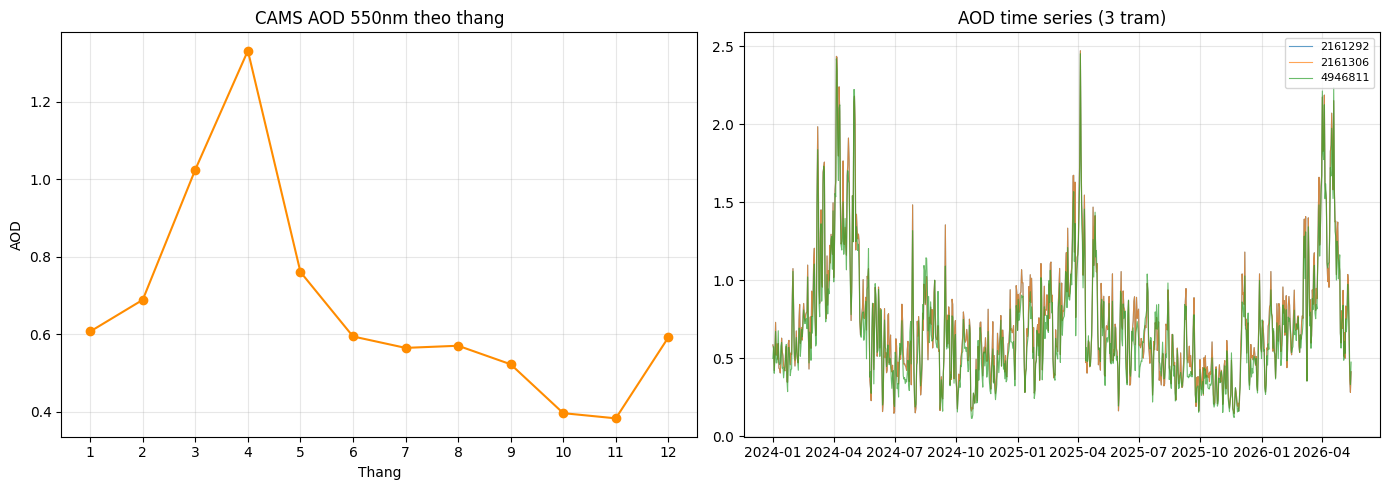

In [7]:
import matplotlib.pyplot as plt

aod_df["month"] = pd.to_datetime(aod_df["date"]).dt.month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = aod_df.groupby("month")["aod_550_mean"].mean()
monthly.plot(ax=axes[0], marker="o", color="darkorange")
axes[0].set_title("CAMS AOD 550nm theo thang", fontsize=12)
axes[0].set_xlabel("Thang"); axes[0].set_ylabel("AOD")
axes[0].set_xticks(range(1,13)); axes[0].grid(alpha=0.3)

for loc_id in list(STATIONS.keys())[:3]:
    sub = aod_df[aod_df["location_id"] == loc_id]
    axes[1].plot(pd.to_datetime(sub["date"]), sub["aod_550_mean"],
                 alpha=0.7, linewidth=0.8, label=str(loc_id))
axes[1].set_title("AOD time series (3 tram)", fontsize=12)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / "outputs/cams_aod_seasonal.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 5 — Correlation AOD vs PM2.5

Pearson r (CAMS AOD vs PM2.5): 0.063  (n=2274)


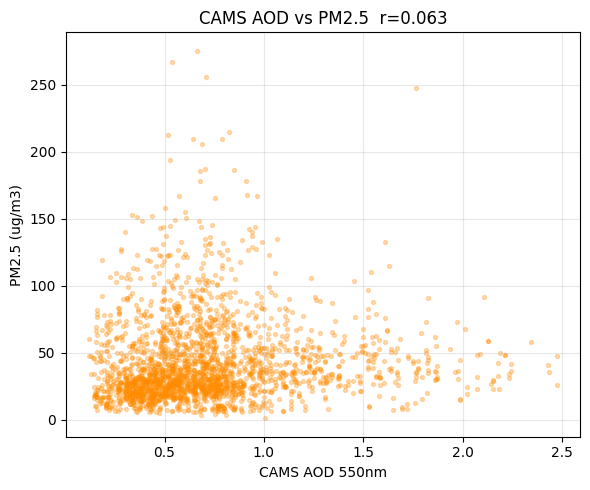

In [8]:
import matplotlib.pyplot as plt

main = pd.read_csv(MERGED, parse_dates=["date"])
aod_df["date"] = pd.to_datetime(aod_df["date"])

check = main.merge(aod_df[["location_id","date","aod_550_mean"]],
                   on=["location_id","date"], how="left")
valid = check[["pm25","aod_550_mean"]].dropna()
r = valid.corr().iloc[0, 1]
print(f"Pearson r (CAMS AOD vs PM2.5): {r:.3f}  (n={len(valid)})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["aod_550_mean"], valid["pm25"], alpha=0.3, s=8, color="darkorange")
ax.set_xlabel("CAMS AOD 550nm"); ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title(f"CAMS AOD vs PM2.5  r={r:.3f}", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "outputs/cams_aod_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 6 — Lưu CSV + Merge vào daily_merged.csv

In [9]:
aod_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}  shape={aod_df.shape}")

main = pd.read_csv(MERGED, parse_dates=["date"])
for col in ["aod_550_mean","aod_550_max","aod_550_morning"]:
    if col in main.columns:
        main.drop(columns=[col], inplace=True)

aod_df["date"] = pd.to_datetime(aod_df["date"])
main = main.merge(
    aod_df[["location_id","date","aod_550_mean","aod_550_max","aod_550_morning"]],
    on=["location_id","date"], how="left"
)

for col in ["aod_550_mean","aod_550_max","aod_550_morning"]:
    pct = main[col].notna().mean()*100
    print(f"  {col}: {pct:.1f}% coverage")

main.to_csv(MERGED, index=False)
print(f"\nUpdated: {MERGED}  shape={main.shape}")

Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\cams_aod_daily.csv  shape=(5196, 6)
  aod_550_mean: 100.0% coverage
  aod_550_max: 100.0% coverage
  aod_550_morning: 100.0% coverage

Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2274, 68)


## Cell 7 — Thêm AOD vào train_3d_v2.py

```python
# ctx_feats (Neural context)
ctx_feats = [..., "aod_550_mean", "aod_550_morning"]

# tab_cols (Tree models)
tab_cols = [..., "aod_550_mean", "aod_550_max", "aod_550_morning"]
```

**Xóa cache + weights trước khi chạy lại:**
```python
import shutil, glob, os
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
for f in glob.glob('outputs/final_3d_v2/neural_seed*.pt'): os.remove(f)
```